Connected to kkumah_conda_env (Python 3.10.11)

In [ ]:
import gc
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.io import loadmat
from datetime import date
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
from matplotlib import gridspec

In [ ]:
cs_ant_month_clim_path = r'/ra1/pubdat/AVHRR_CloudSat_proj/CS_Antartica_analysis_kkk/CS-Antarctica_maps'
gpcp_data_path = r'/ra1/pubdat/Satellite_eval_over_Oceans/data/GPCP/GPCP_v3_pnt_3_monthly'

path_to_put_plots = r'/home/kkumah/Projects/CS-Antarctica_satellite_ratios/GPCP_ratios/plots'

In [ ]:
def ds_swaplon(ds):
    """Swap longitude coordinates from [0,360] to [-180,180] and rename lat/lon."""
    if 'lon' in ds.coords:
        ds = ds.rename({'lon': 'longitude'})
    if 'lat' in ds.coords:
        ds = ds.rename({'lat': 'latitude'})
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
    return ds.sortby('longitude')
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

In [ ]:
mask_path = "/ra1/pubdat/mask_land_ocean/mask50km.mat"
mask = loadmat(mask_path)["mask50"][-60:, :].swapaxes(0, 1)
mask = np.flip(mask, axis=1)
mask_binary = mask < 75
new_mask = mask_binary.copy()
new_mask[:360, :] = mask_binary[360:, :].copy()
new_mask[360:, :] = mask_binary[:360, :].copy()
new_mask = np.flip(new_mask.T, axis=0)
new_mask_ = new_mask.astype(int)

cde_run_dte = str(date.today().strftime('%Y%m%d'))

In [ ]:
gpcp_files_2007_2010 = [
    os.path.join(gpcp_data_path, f) 
    for f in os.listdir(gpcp_data_path) 
    if f.startswith('GPCPMON_L3') and f.split('_')[2][:4] in ['2007', '2008', '2009', '2010'] \
    and f.endswith('.nc4')
]

gpcp_data = xr.open_mfdataset(gpcp_files_2007_2010, combine='by_coords', engine='netcdf4')
gpcp_data = ds_swaplon(gpcp_data)

cs_ant_mnth_clim_filenme = os.path.join(cs_ant_month_clim_path, 'CS-Antarctica_monthly_climatology_2007-2010.nc') 
cs_ant_month_clim = xr.open_dataarray(cs_ant_mnth_clim_filenme, engine='netcdf4')
cs_ant_month_clim = cs_ant_month_clim.where(new_mask_ == 1)

In [ ]:
# Calculate monthly climatology from GPCP data
gpcp_monthly_clim = gpcp_data['sat_gauge_precip'].groupby('time.month').mean(dim='time').compute()

# Subset the data over Antarctica
gpcp_ant_monthly_clim = gpcp_monthly_clim.isel(latitude=slice(-60, None)).where(new_mask_ == 1)

In [ ]:
cs_ant_month_clim_aligned = cs_ant_month_clim.rename({'time': 'month'})

# Ensure latitude and longitude dimensions match
cs_ant_month_clim_aligned = cs_ant_month_clim_aligned.interp(
    lat=gpcp_ant_monthly_clim.latitude, 
    lon=gpcp_ant_monthly_clim.longitude
)

# Initialize an empty dictionary to store results
monthly_ratios = {}

# Loop through each month and compute the ratio
for month in range(1, 13):
    gpcp_month = gpcp_ant_monthly_clim.sel(month=month)
    cs_ant_month = cs_ant_month_clim_aligned.sel(month=month)
    monthly_ratios[month] = cs_ant_month / gpcp_month

# Convert the dictionary back to an xarray DataArray
crfs_arr = xr.concat([monthly_ratios[m] for m in range(1, 13)], dim='month')
crfs_arr = crfs_arr.assign_coords(month=list(range(1, 13)))

<ipython-input-8-178363c7197d>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-8-178363c7197d>:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar


5

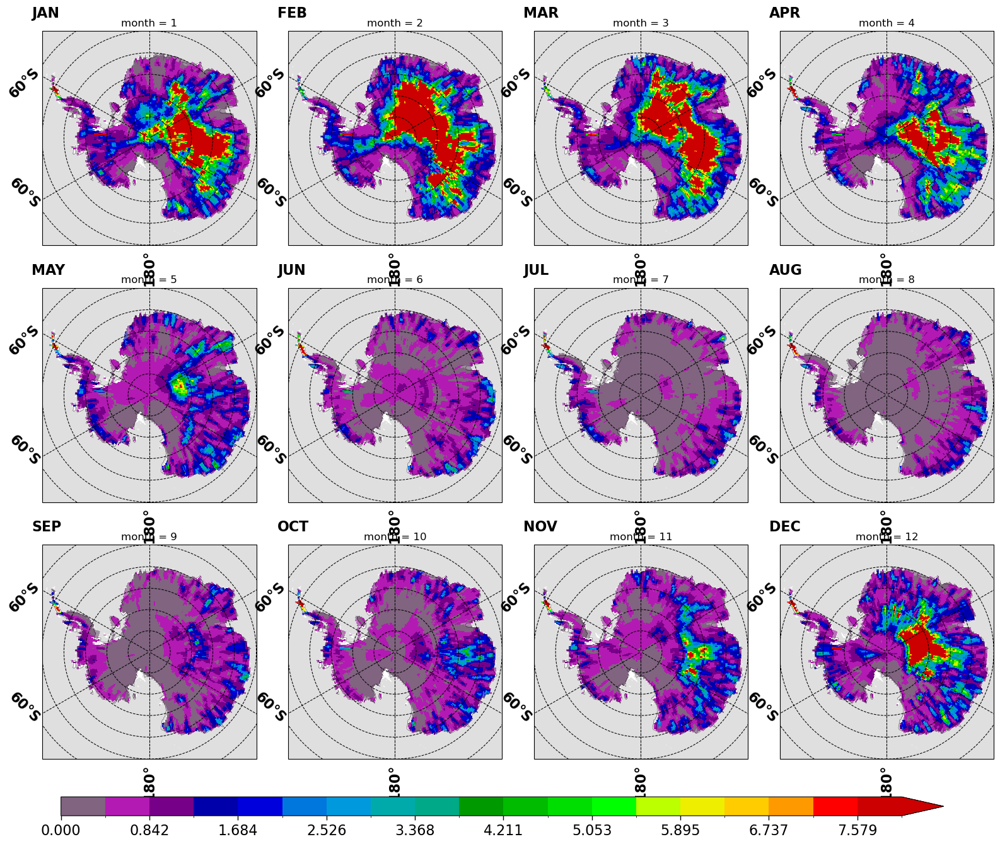

In [ ]:
def plot_correction_ratios(crfs_arr):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = 0, 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
                 vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.text(
            -0.05, 1.05, month_names[month - 1], 
            transform=ax.transAxes, fontsize=16, fontweight='bold', 
            ha='left', va='bottom'
        )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                          linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

    # Add a dedicated axis for the colorbar
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
    cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
    )
    cbar.ax.tick_params(labelsize=16, labelrotation=0, width=1, length=5, direction='out')

    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar

svnme = os.path.join(path_to_put_plots, f'GPCP_ratios_{cde_run_dte}.png')
plot_correction_ratios(crfs_arr)
plt.savefig(svnme, dpi=300)
gc.collect()

<ipython-input-9-dad35d924df4>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-9-dad35d924df4>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar


54871

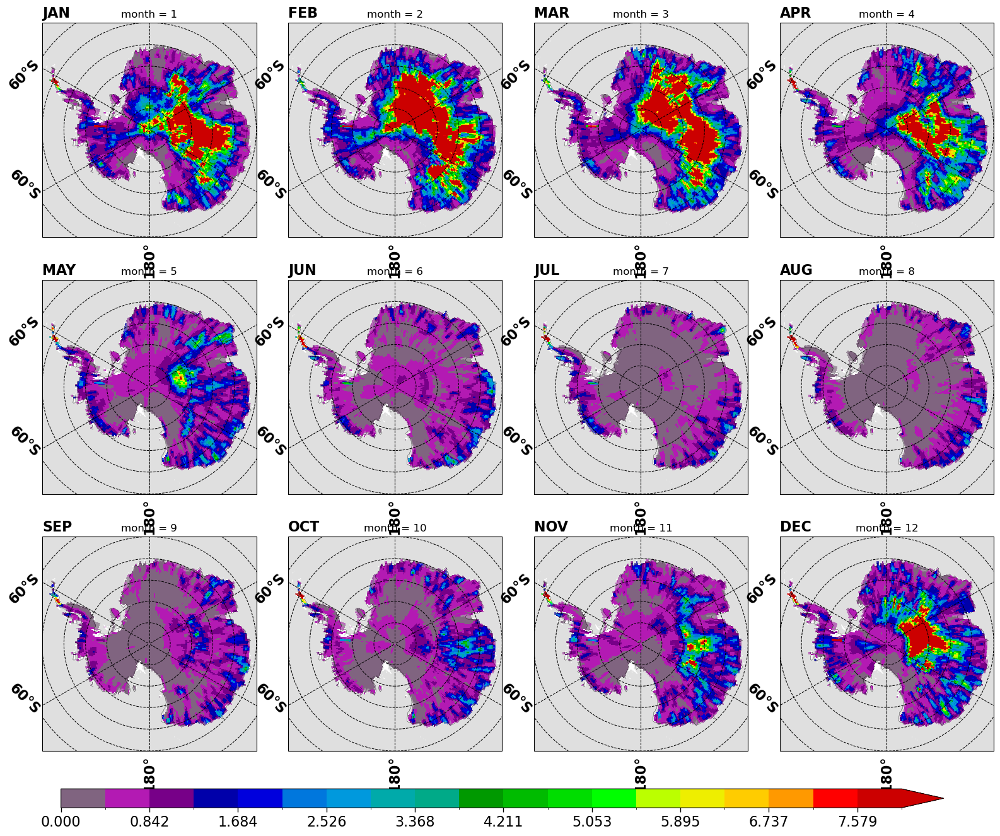

In [ ]:
def plot_correction_ratios(crfs_arr):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = 0, 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
                 vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.set_title(
            month_names[month - 1], 
            loc='left', fontsize=16, fontweight='bold'
        )
        # ax.text(
        #     -0.05, 1.05, month_names[month - 1], 
        #     transform=ax.transAxes, fontsize=16, fontweight='bold', 
        #     ha='left', va='bottom'
        # )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                          linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

    # Add a dedicated axis for the colorbar
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
    cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
    )
    cbar.ax.tick_params(labelsize=16, labelrotation=0, width=1, length=5, direction='out')

    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar

svnme = os.path.join(path_to_put_plots, f'GPCP_ratios_{cde_run_dte}.png')
plot_correction_ratios(crfs_arr)
plt.savefig(svnme, dpi=300)
gc.collect()

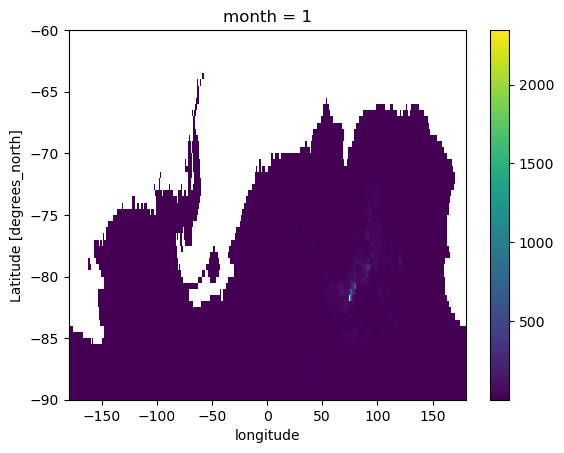

In [ ]:
crfs_arr[0].plot()

<ipython-input-11-750be92ada76>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-11-750be92ada76>:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar


54647

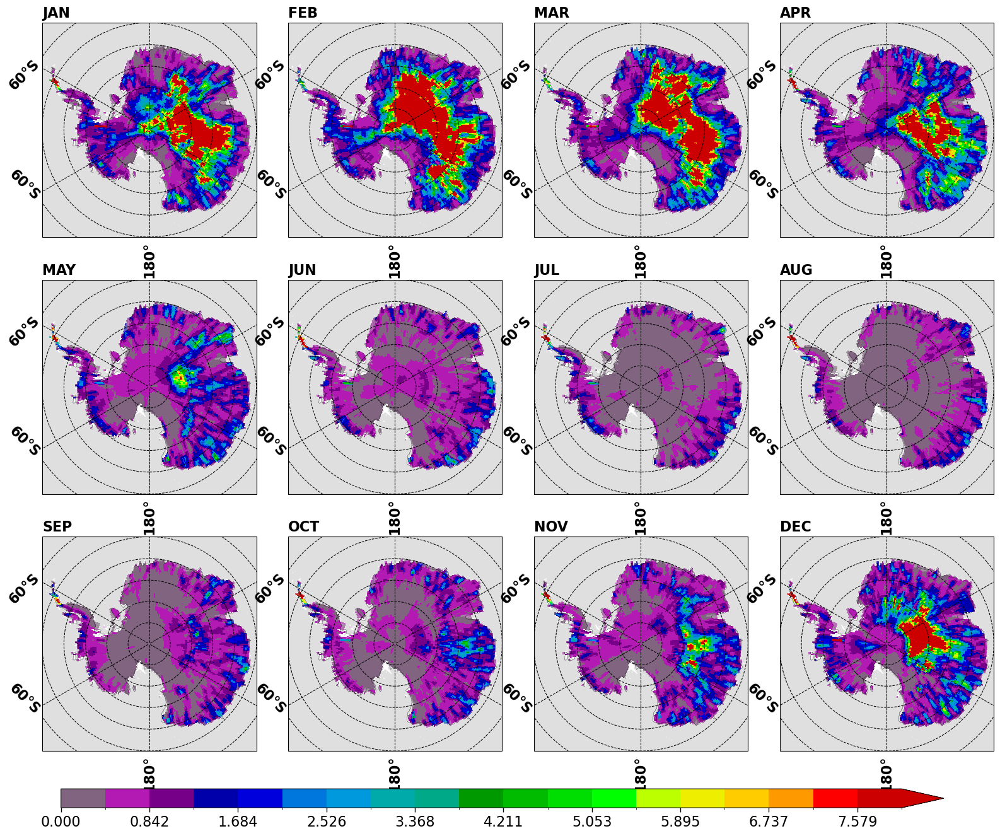

In [ ]:
def plot_correction_ratios(crfs_arr):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = 0, 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
                 vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False, add_labels=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.set_title(
            month_names[month - 1], 
            loc='left', fontsize=16, fontweight='bold'
        )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                          linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

    # Add a dedicated axis for the colorbar
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
    cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
    )
    cbar.ax.tick_params(labelsize=16, labelrotation=0, width=1, length=5, direction='out')

    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar

svnme = os.path.join(path_to_put_plots, f'GPCP_ratios_{cde_run_dte}.png')
plot_correction_ratios(crfs_arr)
plt.savefig(svnme, dpi=300)
gc.collect()

In [ ]:
def plot_correction_ratios(crfs_arr):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = 0, 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
             vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False, add_labels=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.set_title(
            month_names[month - 1], 
            loc='left', fontsize=16, fontweight='bold'
        )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                  linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

        # Add a dedicated axis for the colorbar
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
        )
        cbar.ax.tick_params(labelsize=16, labelrotation=0, width=1, length=5, direction='out')

        # Round colorbar tick labels to 1 decimal place
        cbar.ax.set_xticklabels([f"{tick:.1f}" for tick in cbar.get_ticks()])

        # Adjust layout
        plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar

<ipython-input-12-a0abe5c3a7d3>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)


ValueError: The number of FixedLocator locations (20), usually from a call to set_ticks, does not match the number of labels (10).

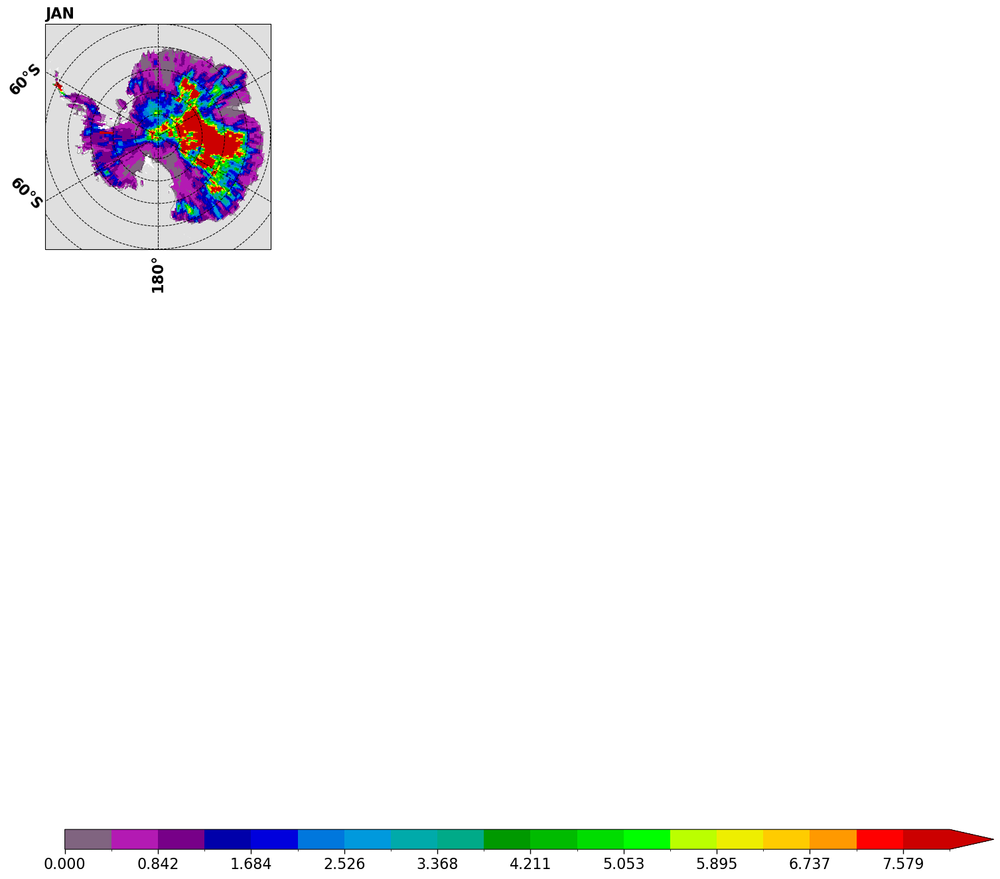

In [ ]:
svnme = os.path.join(path_to_put_plots, f'GPCP_ratios_{cde_run_dte}.png')
plot_correction_ratios(crfs_arr)
plt.savefig(svnme, dpi=300)
gc.collect()

<ipython-input-14-b12aa667fca3>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-14-b12aa667fca3>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-14-b12aa667fca3>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-14-b12aa667fca3>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-14-b12aa667fca3>:72: 

5

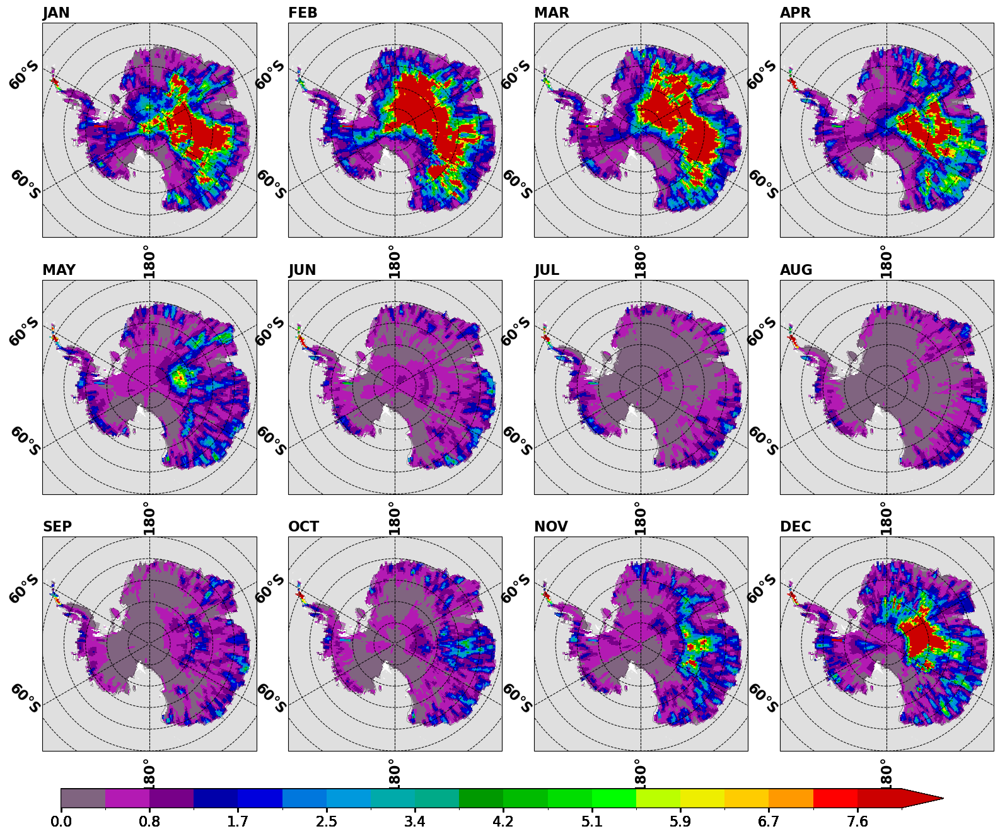

In [ ]:
def plot_correction_ratios(crfs_arr):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = 0, 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
             vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False, add_labels=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.set_title(
            month_names[month - 1], 
            loc='left', fontsize=16, fontweight='bold'
        )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                  linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

        # Add a dedicated axis for the colorbar
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
        )
        cbar.ax.tick_params(labelsize=16, labelrotation=0, width=1, length=5, direction='out')

        # Round colorbar tick labels to 1 decimal place
        ticks = cbar.get_ticks()
        cbar.ax.set_xticks(ticks)
        cbar.ax.set_xticklabels([f"{tick:.1f}" for tick in ticks])

        # Adjust layout
        plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar

svnme = os.path.join(path_to_put_plots, f'GPCP_ratios_{cde_run_dte}.png')
plot_correction_ratios(crfs_arr)
plt.savefig(svnme, dpi=300)
gc.collect()

<ipython-input-15-15d9a9897d95>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-15-15d9a9897d95>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-15-15d9a9897d95>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-15-15d9a9897d95>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-15-15d9a9897d95>:72: 

97361

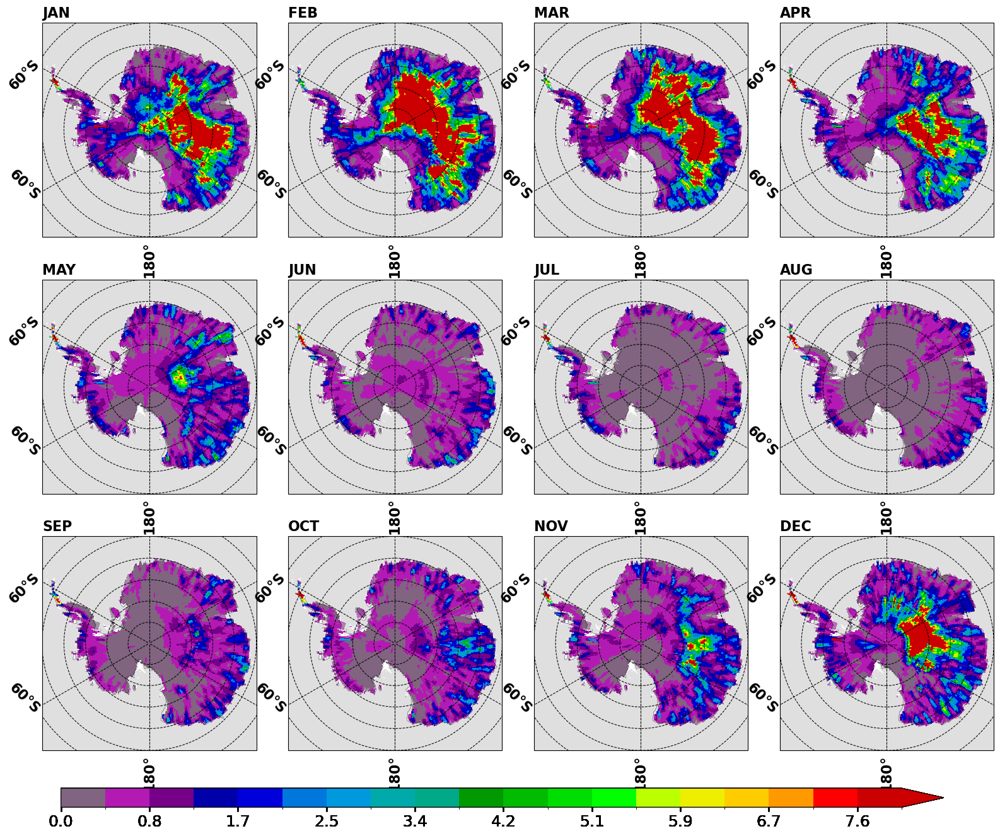

In [ ]:
def plot_correction_ratios(crfs_arr):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = 0, 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
             vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False, add_labels=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.set_title(
            month_names[month - 1], 
            loc='left', fontsize=16, fontweight='bold'
        )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                  linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

        # Add a dedicated axis for the colorbar
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
        )
        cbar.ax.tick_params(labelsize=18, labelrotation=0, width=1, length=5, direction='out')

        # Round colorbar tick labels to 1 decimal place
        ticks = cbar.get_ticks()
        cbar.ax.set_xticks(ticks)
        cbar.ax.set_xticklabels([f"{tick:.1f}" for tick in ticks])

        # Adjust layout
        plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar

svnme = os.path.join(path_to_put_plots, f'GPCP_ratios_{cde_run_dte}.png')
plot_correction_ratios(crfs_arr)
plt.savefig(svnme, dpi=300)
gc.collect()

In [ ]:
import pandas as pd

In [ ]:
# Calculate single value correction ratios and store them in a DataFrame
crfs_arr_single = [
    {
        'month': month,
        'crf': (cs_ant_month_clim_aligned.sel(month=month).mean().item() /
                gpcp_ant_monthly_clim.sel(month=month).mean().item())
    }
    for month in range(1, 13)
]

# Convert the list of dictionaries to a DataFrame
crfs_arr_single = pd.DataFrame(crfs_arr_single)

In [ ]:
crfs_arr_single

,month,crf
0,1,0.979328
1,2,1.181088
2,3,1.063509
3,4,1.003165
4,5,0.772703
5,6,0.643759
6,7,0.541634
7,8,0.482277
8,9,0.480045
9,10,0.692928


In [ ]:
import gc
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.io import loadmat
from datetime import date
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
from matplotlib import gridspec
import matplotlib as mpl

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the f

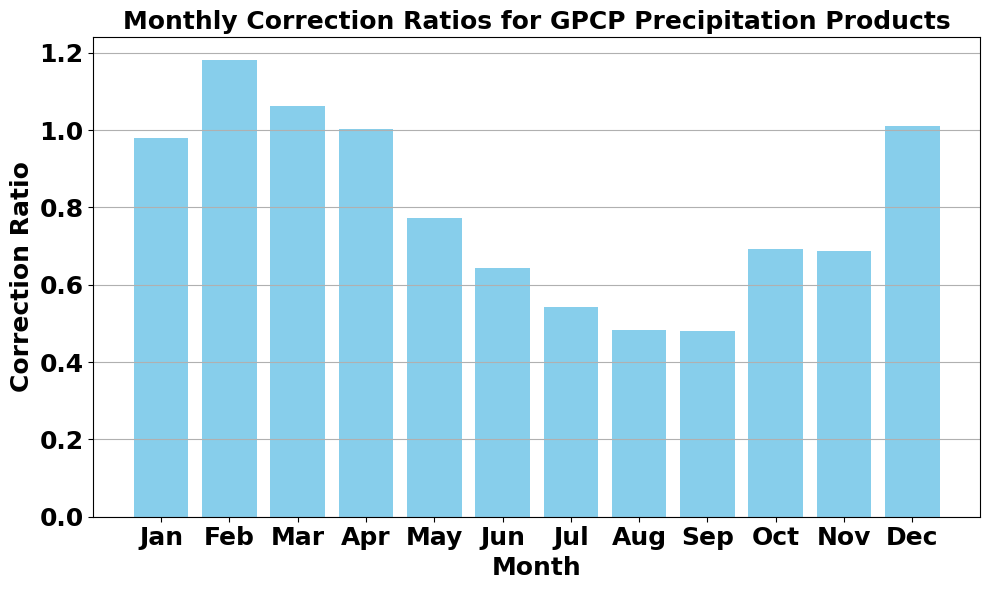

In [ ]:
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'serif']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Create the bar plot with updated styles
plt.figure(figsize=(10, 6))
plt.bar(crfs_arr_single['month'], crfs_arr_single['crf'], color='skyblue')
plt.xticks(crfs_arr_single['month'], 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=18, fontweight='bold')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold')
plt.title('Monthly Correction Ratios for GPCP Precipitation Products', fontsize=18, fontweight='bold')
plt.grid(axis='y')
plt.tight_layout()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, serif
findfont: Generic family 'serif' not found because n

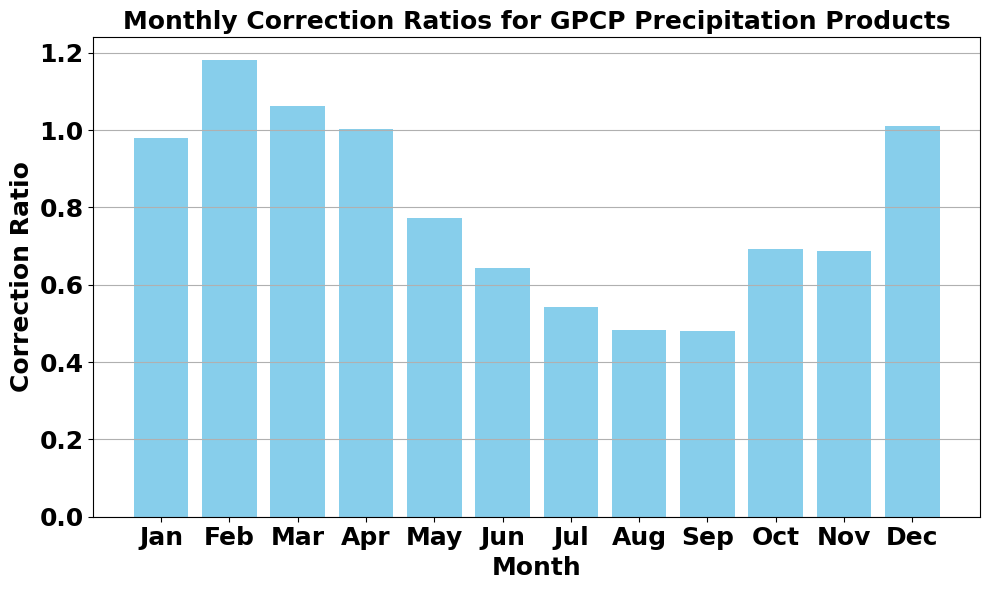

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(crfs_arr_single['month'], crfs_arr_single['crf'], color='skyblue')
plt.xticks(crfs_arr_single['month'], 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios for GPCP Precipitation Products', fontsize=18, fontweight='bold', family='Times New Roman')
plt.grid(axis='y')
plt.tight_layout()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

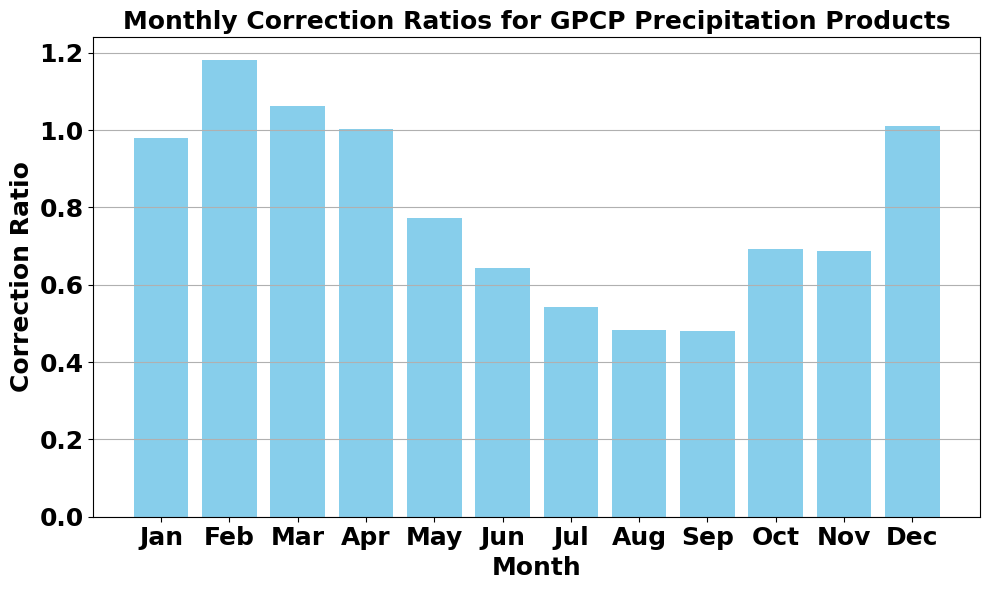

In [ ]:
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Create the bar plot with updated styles
plt.figure(figsize=(10, 6))
plt.bar(crfs_arr_single['month'], crfs_arr_single['crf'], color='skyblue')
plt.xticks(crfs_arr_single['month'], 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios for GPCP Precipitation Products', fontsize=18, fontweight='bold', family='Times New Roman')
plt.grid(axis='y')
plt.tight_layout()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

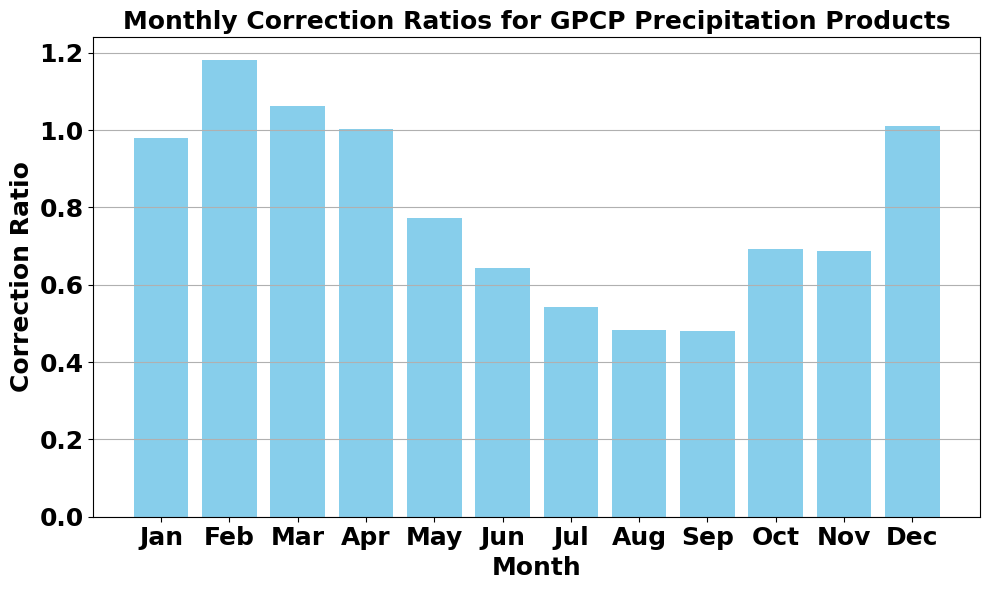

In [ ]:
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Create the bar plot with updated styles
plt.figure(figsize=(10, 6))
plt.bar(crfs_arr_single['month'], crfs_arr_single['crf'], color='skyblue')
plt.xticks(crfs_arr_single['month'], 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios for GPCP Precipitation Products', fontsize=18, fontweight='bold', family='Times New Roman')
plt.grid(axis='y')
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(path_to_put_plots, f'GPCP_ratios_single_{cde_run_dte}.png'), dpi=300)
plt.show()

In [ ]:
1/3

0.3333333333333333

In [ ]:
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

def cf_calculator(reference, target, mask, quantile=1 - 1e-6):
    product_land = np.where(mask, target, np.nan)
    q99 = np.nanquantile(product_land, quantile)
    new_product = np.where(product_land > q99, q99, target)
    new_product = np.where(~mask, target, new_product)
    product_smoothed = apply_filter(new_product)

    return reference / product_smoothed

def apply_filter(
    array, method="convolution", sigma=1.4, kernel=np.ones((5, 5))
):
    if method == "gaussian":
        new_array = gaussian_filter(array, sigma=(sigma, sigma), order=0)
    elif method == "convolution":
        new_array = convolve2d(array, kernel, boundary="symm", mode="same")
        new_array = new_array / kernel.sum()

    return new_array

In [ ]:
crfs_arr_reza = xr.concat(
    [
        xr.DataArray(
            cf_calculator(
                cs_ant_month_clim_aligned.sel(month=month).values,
                gpcp_ant_monthly_clim.sel(month=month).values,
                new_mask_,
            ),
            dims=["latitude", "longitude"],
            coords={
                "latitude": gpcp_ant_monthly_clim.latitude,
                "longitude": gpcp_ant_monthly_clim.longitude,
                "month": month,
            },
        )
        for month in range(1, 13)
    ],
    dim="month",
)
crfs_arr_reza = crfs_arr_reza.assign_coords(month=list(range(1, 13)))

In [ ]:
crfs_arr_reza

<xarray.DataArray (month: 12, latitude: 60, longitude: 720)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [2.65090298, 2.65539186, 2.66491337, ..., 2.63619036,
         2.63495022, 2.63084387],
        [3.83157519, 3.83427956, 3.84150497, ..., 3.79143975,
         3.80074089, 3.80671727],
        [4.8830881 , 4.88755453, 4.89751593, ..., 4.82792836,
         4.84190914, 4.85002235]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.45300198, 0.45324704, 0.45458027, ..., 0.44781503,
         0.44842889, 0.44835999],
        [0.49197432, 0.49233071, 0.49336278, ..., 0.48795837,
         0.48860532, 0.48869276],
        [0.52177738, 0.5222232 , 0.52333051, ..., 0.51514062,
         0.51674554, 0.51759417]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.71940215, 0.72050565, 0.72383738, ..., 0.71182996,
         0.71190938, 0.71046699],
        [0.77507942, 0.77761553, 0.78166776, ..., 0.76784182,
         0.76797823, 0.76686198],
        [0.85467008, 0.85718654, 0.86116695, ..., 0.8407924 ,
         0.84331314, 0.84427266]]])
Coordinates:
  * latitude   (latitude) float32 -60.25 -60.75 -61.25 ... -88.75 -89.25 -89.75
  * longitude  (longitude) float32 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [ ]:
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

def cf_calculator(reference, target, mask, quantile=1 - 1e-6):
    product_land = np.where(mask, target, np.nan)
    q99 = np.nanquantile(product_land, quantile)
    new_product = np.where(product_land > q99, q99, target)
    new_product = np.where(~mask, target, new_product)
    product_smoothed = apply_filter(new_product)

    return reference / product_smoothed

def apply_filter(
    array, method="convolution", sigma=1.4, kernel=np.ones((5, 5))
):
    if method == "gaussian":
        new_array = gaussian_filter(array, sigma=(sigma, sigma), order=0)
    elif method == "convolution":
        new_array = convolve2d(array, kernel, boundary="symm", mode="same")
        new_array = new_array / kernel.sum()

    return new_array

CAP = 3


def apply_cap(array, minimum=1 / CAP, maximum=CAP):
    temp = np.where(array > maximum, maximum, array)
    temp = np.where(temp < minimum, minimum, temp)

    return temp


def get_zonal(spatial_product, mask, y, axis=(0, 1)):
    cosines = np.cos(np.radians(y))
    cosines = np.where(mask, cosines, 0)
    weights = cosines / np.nansum(cosines)

    return np.nansum(weights * spatial_product, axis=axis)


def cf_smoother(reference, target, cf, mask, y):
    # cf_smoothed = apply_filter(cf)
    cf_capped = apply_cap(cf)
    zonal_reference = get_zonal(reference, mask, y)
    zonal_product = get_zonal(target * cf_capped, mask, y)
    ratio = zonal_reference / zonal_product
    i = 1
    while (abs(1 - ratio) > 1e-3) and (i < 5):
        apply_conditional = (cf_capped <= CAP) & (cf_capped >= 1 / CAP)
        cf_capped = np.where(apply_conditional, cf_capped * ratio, cf_capped)
        zonal_product = get_zonal(target * cf_capped, mask, y)
        ratio = zonal_reference / zonal_product
        i += 1

    return cf_capped

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Calculate correction factors using the Reza method
crfs_arr_reza = xr.concat(
    [
        xr.DataArray(
            cf_calculator(
                cs_ant_month_clim_aligned.sel(month=month).values,
                gpcp_ant_monthly_clim.sel(month=month).values,
                new_mask_,
            ),
            dims=["latitude", "longitude"],
            coords={
                "latitude": gpcp_ant_monthly_clim.latitude,
                "longitude": gpcp_ant_monthly_clim.longitude,
                "month": month,
            },
        )
        for month in range(1, 13)
    ],
    dim="month",
)
crfs_arr_reza = crfs_arr_reza.assign_coords(month=list(range(1, 13)))

# apply the smoothing and zonal averaging
crfs_arr_reza_smoothed = xr.concat(
    [
        xr.DataArray(
            cf_smoother(
                cs_ant_month_clim_aligned.sel(month=month).values,
                gpcp_ant_monthly_clim.sel(month=month).values,
                crfs_arr_reza.sel(month=month).values,
                new_mask_,
                gpcp_ant_monthly_clim.latitude.values,
            ),
            dims=["latitude", "longitude"],
            coords={
                "latitude": gpcp_ant_monthly_clim.latitude,
                "longitude": gpcp_ant_monthly_clim.longitude,    
                "month": month,
            },
        )
        for month in range(1, 13)
    ],
    dim="month",
)
crfs_arr_reza_smoothed = crfs_arr_reza_smoothed.assign_coords(month=list(range(1, 13)))

ValueError: operands could not be broadcast together with shapes (60,720) (60,) () 

In [ ]:
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

def cf_calculator(reference, target, mask, quantile=1 - 1e-6):
    product_land = np.where(mask, target, np.nan)
    q99 = np.nanquantile(product_land, quantile)
    new_product = np.where(product_land > q99, q99, target)
    new_product = np.where(~mask, target, new_product)
    product_smoothed = apply_filter(new_product)

    return reference / product_smoothed

def apply_filter(
    array, method="convolution", sigma=1.4, kernel=np.ones((5, 5))
):
    if method == "gaussian":
        new_array = gaussian_filter(array, sigma=(sigma, sigma), order=0)
    elif method == "convolution":
        new_array = convolve2d(array, kernel, boundary="symm", mode="same")
        new_array = new_array / kernel.sum()

    return new_array

CAP = 3


def apply_cap(array, minimum=1 / CAP, maximum=CAP):
    temp = np.where(array > maximum, maximum, array)
    temp = np.where(temp < minimum, minimum, temp)

    return temp


def get_zonal(spatial_product, mask, y, axis=(0, 1)):
    cosines = np.cos(np.radians(y))[:, np.newaxis]  # Broadcast to match mask shape
    cosines = np.where(mask, cosines, 0)
    weights = cosines / np.nansum(cosines)

    return np.nansum(weights * spatial_product, axis=axis)


def cf_smoother(reference, target, cf, mask, y):
    # cf_smoothed = apply_filter(cf)
    cf_capped = apply_cap(cf)
    zonal_reference = get_zonal(reference, mask, y)
    zonal_product = get_zonal(target * cf_capped, mask, y)
    ratio = zonal_reference / zonal_product
    i = 1
    while (abs(1 - ratio) > 1e-3) and (i < 5):
        apply_conditional = (cf_capped <= CAP) & (cf_capped >= 1 / CAP)
        cf_capped = np.where(apply_conditional, cf_capped * ratio, cf_capped)
        zonal_product = get_zonal(target * cf_capped, mask, y)
        ratio = zonal_reference / zonal_product
        i += 1

    return cf_capped

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# Calculate correction factors using the Reza method
crfs_arr_reza = xr.concat(
    [
        xr.DataArray(
            cf_calculator(
                cs_ant_month_clim_aligned.sel(month=month).values,
                gpcp_ant_monthly_clim.sel(month=month).values,
                new_mask_,
            ),
            dims=["latitude", "longitude"],
            coords={
                "latitude": gpcp_ant_monthly_clim.latitude,
                "longitude": gpcp_ant_monthly_clim.longitude,
                "month": month,
            },
        )
        for month in range(1, 13)
    ],
    dim="month",
)
crfs_arr_reza = crfs_arr_reza.assign_coords(month=list(range(1, 13)))

# apply the smoothing and zonal averaging
crfs_arr_reza_smoothed = xr.concat(
    [
        xr.DataArray(
            cf_smoother(
                cs_ant_month_clim_aligned.sel(month=month).values,
                gpcp_ant_monthly_clim.sel(month=month).values,
                crfs_arr_reza.sel(month=month).values,
                new_mask_,
                gpcp_ant_monthly_clim.latitude.values,
            ),
            dims=["latitude", "longitude"],
            coords={
                "latitude": gpcp_ant_monthly_clim.latitude,
                "longitude": gpcp_ant_monthly_clim.longitude,    
                "month": month,
            },
        )
        for month in range(1, 13)
    ],
    dim="month",
)
crfs_arr_reza_smoothed = crfs_arr_reza_smoothed.assign_coords(month=list(range(1, 13)))

In [ ]:
crfs_arr_reza_smoothed

<xarray.DataArray (month: 12, latitude: 60, longitude: 720)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [5.62079365, 5.63031158, 5.65050033, ..., 5.58959802,
         5.5869685 , 5.57826168],
        [6.36099513, 6.36099513, 6.36099513, ..., 6.36099513,
         6.36099513, 6.36099513],
        [6.36099513, 6.36099513, 6.36099513, ..., 6.36099513,
         6.36099513, 6.36099513]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.92437794, 0.924878  , 0.92759855, ..., 0.91379367,
         0.91504629, 0.91490569],
        [1.00390337, 1.0046306 , 1.00673659, ..., 0.99570859,
         0.99702872, 0.99720714],
        [1.06471831, 1.06562804, 1.06788757, ..., 1.0511756 ,
         1.05445053, 1.05618222]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [1.57269413, 1.57510651, 1.58239004, ..., 1.55614047,
         1.55631408, 1.55316086],
        [1.6944109 , 1.69995514, 1.70881375, ..., 1.6785887 ,
         1.6788869 , 1.67644667],
        [1.86840506, 1.87390633, 1.88260795, ..., 1.83806689,
         1.84357751, 1.84567512]]])
Coordinates:
  * latitude   (latitude) float32 -60.25 -60.75 -61.25 ... -88.75 -89.25 -89.75
  * longitude  (longitude) float32 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

<ipython-input-15-15d9a9897d95>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-15-15d9a9897d95>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-15-15d9a9897d95>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-15-15d9a9897d95>:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-15-15d9a9897d95>:72: 

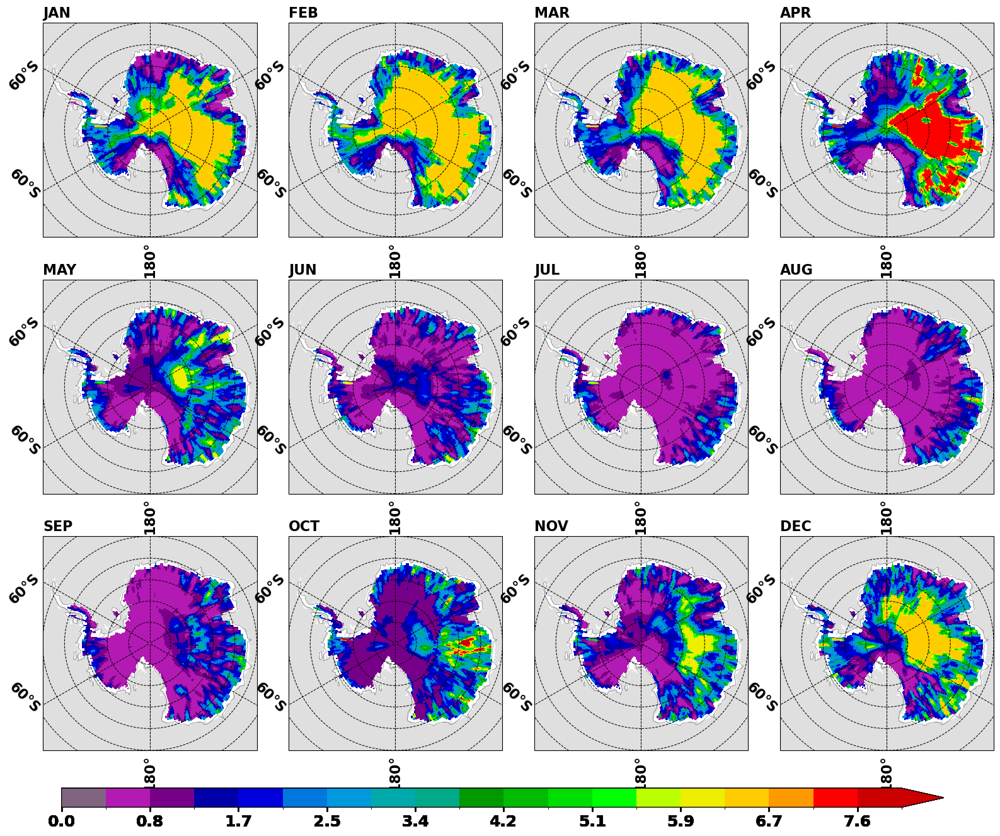

In [ ]:
plot_correction_ratios(crfs_arr_reza_smoothed)

In [ ]:
def ds_swaplon(ds):
    """Swap longitude coordinates from [0,360] to [-180,180] and rename lat/lon."""
    if 'lon' in ds.coords:
        ds = ds.rename({'lon': 'longitude'})
    if 'lat' in ds.coords:
        ds = ds.rename({'lat': 'latitude'})
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180))
    return ds.sortby('longitude')
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# plot the correction ratios
def plot_correction_ratios(crfs_arr, vmin=None, vmax=None):
    """
    Plots the correction ratios for each month in a 3x4 grid.

    Parameters:
    crfs_arr (xarray.DataArray): Correction ratios with dimensions (month, latitude, longitude).
    """
    proj = ccrs.SouthPolarStereo()

    # Define the custom colormap
    mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
    ncolors = mpl_cm(np.linspace(0, 1, 21))[:20]
    ncolors[0] = [128 / 256, 100 / 256, 128 / 256, 1]
    ncolors[2] = ncolors[1].copy()
    ncolors[1] = [0.7, 0.1, 0.7, 1]
    newcmap = ListedColormap(ncolors)

    # Set discrete color levels
    vmin, vmax = vmin or 0, vmax or 8  # Increased vmax to address white areas in the map
    levels = np.linspace(vmin, vmax, len(ncolors))
    norm = BoundaryNorm(levels, newcmap.N)

    # Create a GridSpec for better control over the layout
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(3, 4, figure=fig, wspace=0.025, hspace=0.2)

    month_names = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    axes = []

    for month in range(1, 13):
        ax = fig.add_subplot(gs[month - 1], projection=proj)
        ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
        ax.coastlines(lw=0.25, resolution="110m", zorder=2)

        # Plot the correction ratio for the current month
        crf = crfs_arr.sel(month=month)
        crf.plot(ax=ax, transform=ccrs.PlateCarree(), 
             vmin=vmin, vmax=vmax, cmap=newcmap, norm=norm, add_colorbar=False, add_labels=False)

        ax.add_feature(cfeature.OCEAN, zorder=1, edgecolor=None, lw=0, color="silver", alpha=0.5)

        # Place the title on the left without "month = number"
        ax.set_title(
            month_names[month - 1], 
            loc='left', fontsize=16, fontweight='bold'
        )

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, 
                  linestyle='--', color='k', linewidth=0.75)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 16, 'fontweight': 'bold'}
        gl.ylabel_style = {'fontsize': 16, 'fontweight': 'bold'}

        axes.append(ax)

        # Add a dedicated axis for the colorbar
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=newcmap),
        cax=cbar_ax, orientation='horizontal', extend='max'
        )
        cbar.ax.tick_params(labelsize=18, labelrotation=0, width=1, length=5, direction='out')

        # Round colorbar tick labels to 1 decimal place
        ticks = cbar.get_ticks()
        cbar.ax.set_xticks(ticks)
        cbar.ax.set_xticklabels([f"{tick:.1f}" for tick in ticks])

        # Adjust layout
        plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

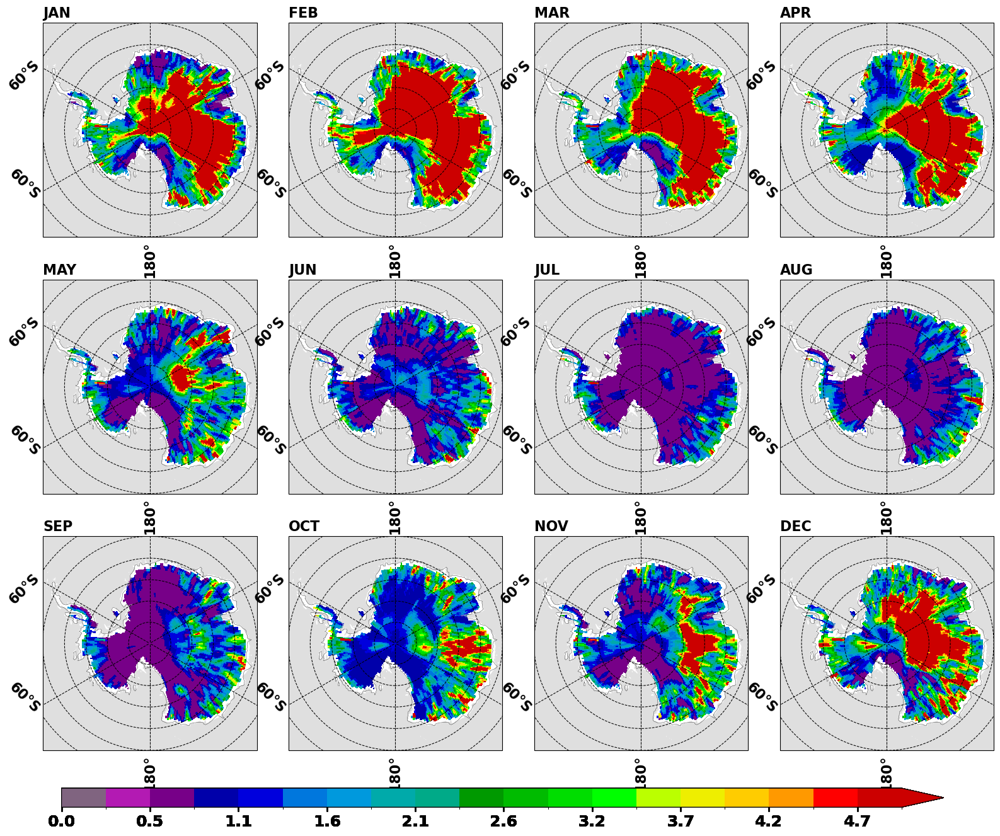

In [ ]:
plot_correction_ratios(crfs_arr_reza_smoothed, vmin=0, vmax=5)

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

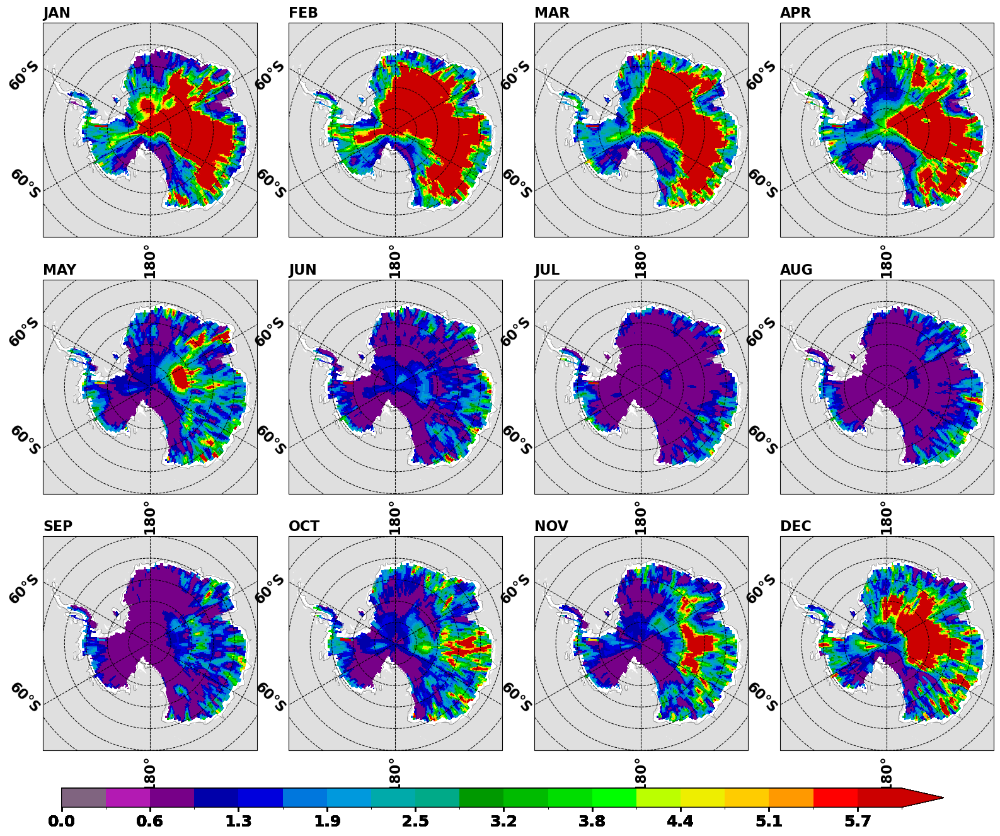

In [ ]:
plot_correction_ratios(crfs_arr_reza_smoothed, vmin=0, vmax=6)

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

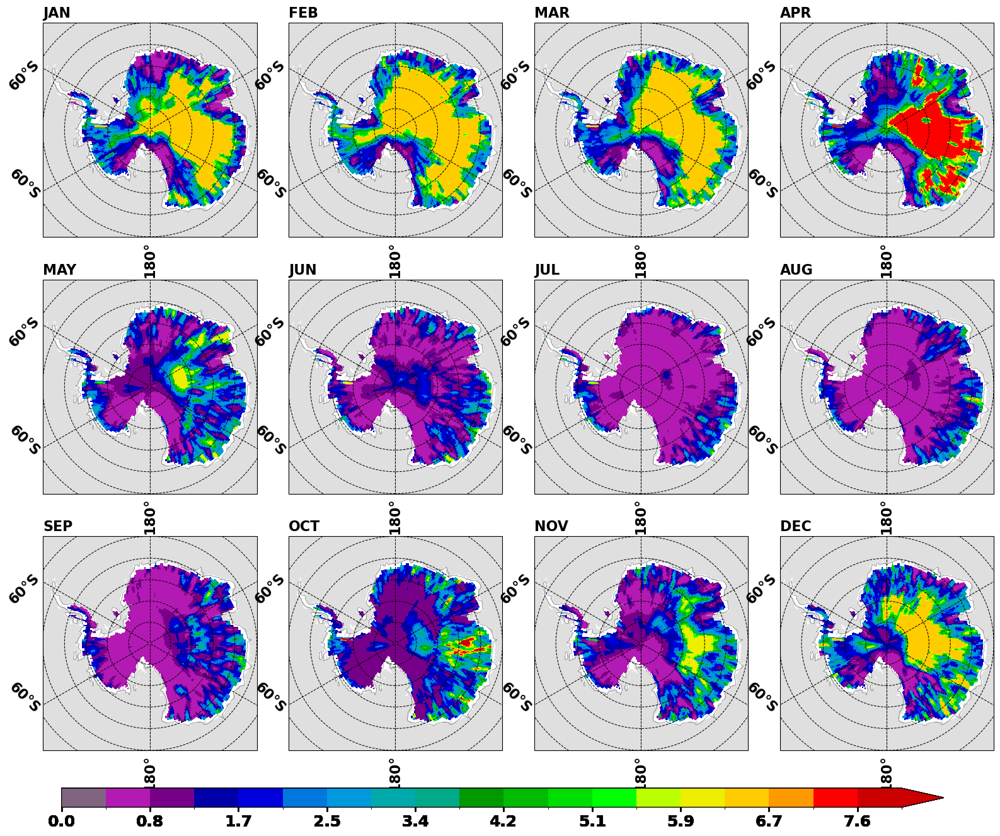

In [ ]:
plot_correction_ratios(crfs_arr_reza_smoothed, vmin=0, vmax=8)

In [ ]:
crfs_arr_reza_single = [
    {
        'month': month,
        'crf': crfs_arr_reza_smoothed.sel(month=month).mean().item()
    }
    for month in range(1, 13)
]

# Convert the list of dictionaries to a DataFrame
crfs_arr_reza_single = pd.DataFrame(crfs_arr_reza_single)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

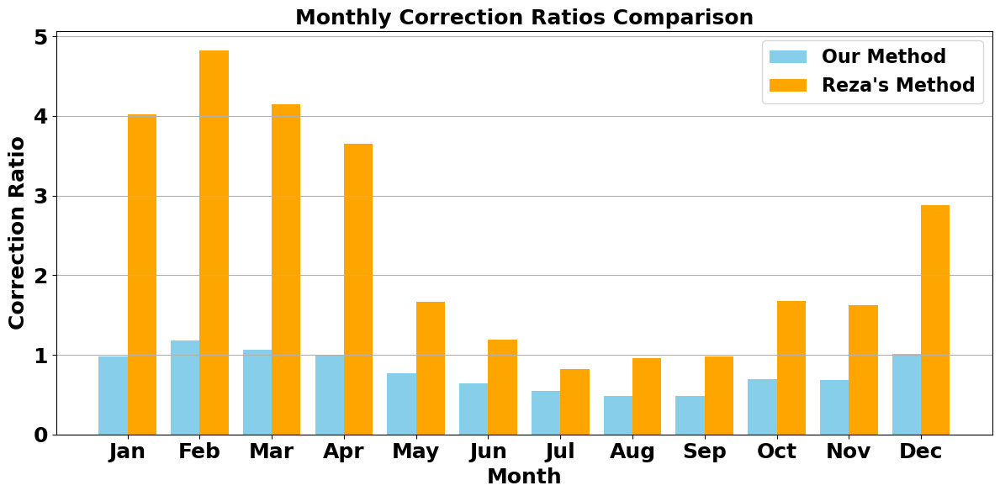

In [ ]:
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Combine data for both methods
width = 0.4  # Width of each bar
x = np.arange(1, 13)  # Month indices

# Create the bar plot with updated styles
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, crfs_arr_single['crf'], width, label='Our Method', color='skyblue')
plt.bar(x + width / 2, crfs_arr_reza_single['crf'], width, label='Reza\'s Method', color='orange')

# Add labels and title
plt.xticks(x, 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios Comparison', fontsize=18, fontweight='bold', family='Times New Roman')

# Add grid and legend
plt.grid(axis='y')
plt.legend(fontsize=16, loc='upper right', frameon=True)
plt.tight_layout()

In [ ]:
crfs_arr_reza_single

,month,crf
0,1,4.017122
1,2,4.820851
2,3,4.144487
3,4,3.648207
4,5,1.664340
5,6,1.190876
6,7,0.824230
7,8,0.956680
8,9,0.979884
9,10,1.674751


<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

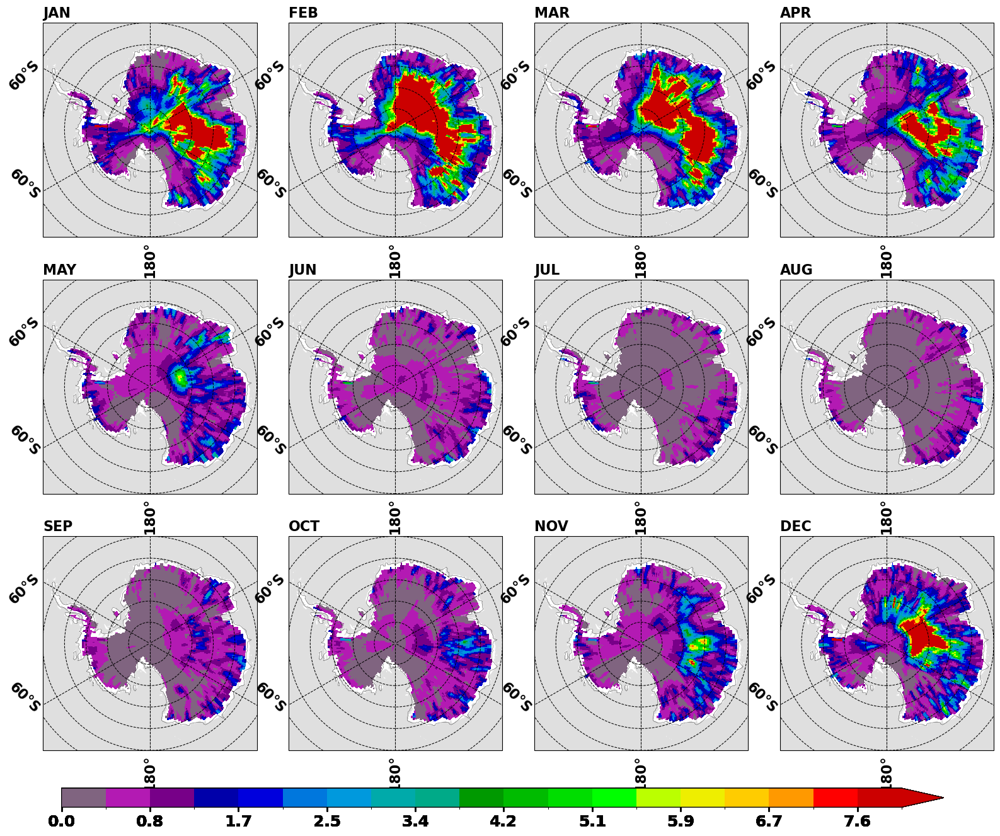

In [ ]:
plot_correction_ratios(crfs_arr_reza, vmin=0, vmax=8)




findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

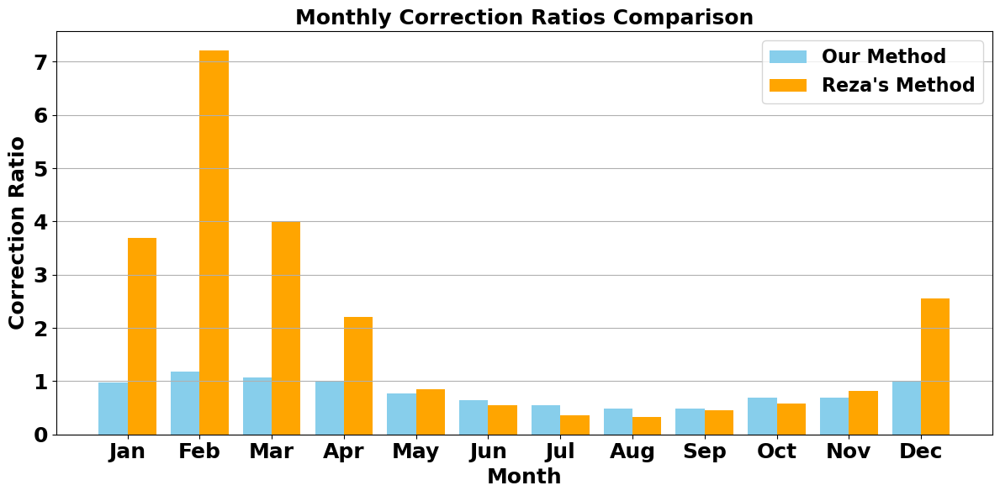

In [ ]:
crfs_arr_reza_single = [
    {
        'month': month,
        'crf': crfs_arr_reza.sel(month=month).mean().item()
    }
    for month in range(1, 13)
]

# Convert the list of dictionaries to a DataFrame
crfs_arr_reza_single = pd.DataFrame(crfs_arr_reza_single)

# make a bar plot of the single value correction ratios
# Update matplotlib parameters for improved aesthetics
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Combine data for both methods
width = 0.4  # Width of each bar
x = np.arange(1, 13)  # Month indices

# Create the bar plot with updated styles
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, crfs_arr_single['crf'], width, label='Our Method', color='skyblue')
plt.bar(x + width / 2, crfs_arr_reza_single['crf'], width, label='Reza\'s Method', color='orange')

# Add labels and title
plt.xticks(x, 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios Comparison', fontsize=18, fontweight='bold', family='Times New Roman')

# Add grid and legend
plt.grid(axis='y')
plt.legend(fontsize=16, loc='upper right', frameon=True)
plt.tight_layout()

In [ ]:
crfs_arr_single_ = [
    {
        'month': month,
        'crf': crfs_arr.sel(month=month).mean().item()
    }
    for month in range(1, 13)
]
# Convert the list of dictionaries to a DataFrame
crfs_arr_single_ = pd.DataFrame(crfs_arr_single_)

<Axes: >

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

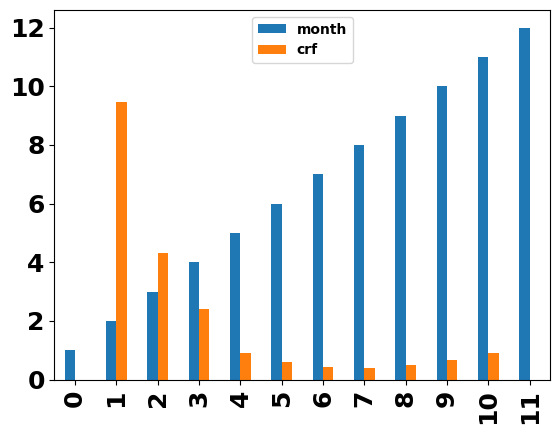

In [ ]:
crfs_arr_single_.plot(kind='bar')

In [ ]:
crfs_arr_single_

,month,crf
0,1,inf
1,2,9.451676
2,3,4.320270
3,4,2.393810
4,5,0.917503
5,6,0.604038
6,7,0.422020
7,8,0.403432
8,9,0.511637
9,10,0.653843


<Axes: xlabel='month'>

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

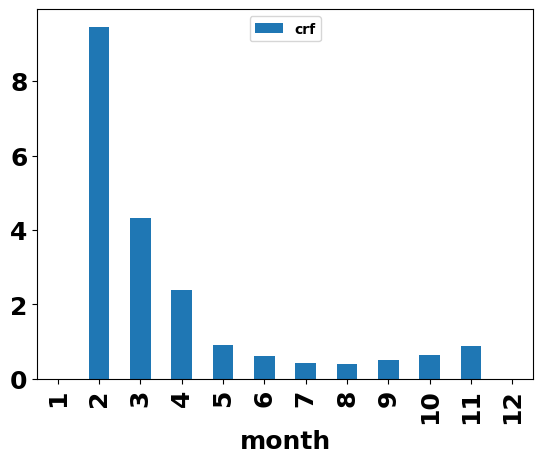

In [ ]:
crfs_arr_single_.plot(kind='bar',x='month',y='crf')

In [ ]:
crfs_arr_single_

,month,crf
0,1,inf
1,2,9.451676
2,3,4.320270
3,4,2.393810
4,5,0.917503
5,6,0.604038
6,7,0.422020
7,8,0.403432
8,9,0.511637
9,10,0.653843


In [ ]:
crfs_arr.sel(month=month).mean(dim=['latitude', 'longitude']).item()

inf

In [ ]:
crfs_arr.sel(month=month).mean(dim=['latitude', 'longitude'], skipna=True).item()

inf

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

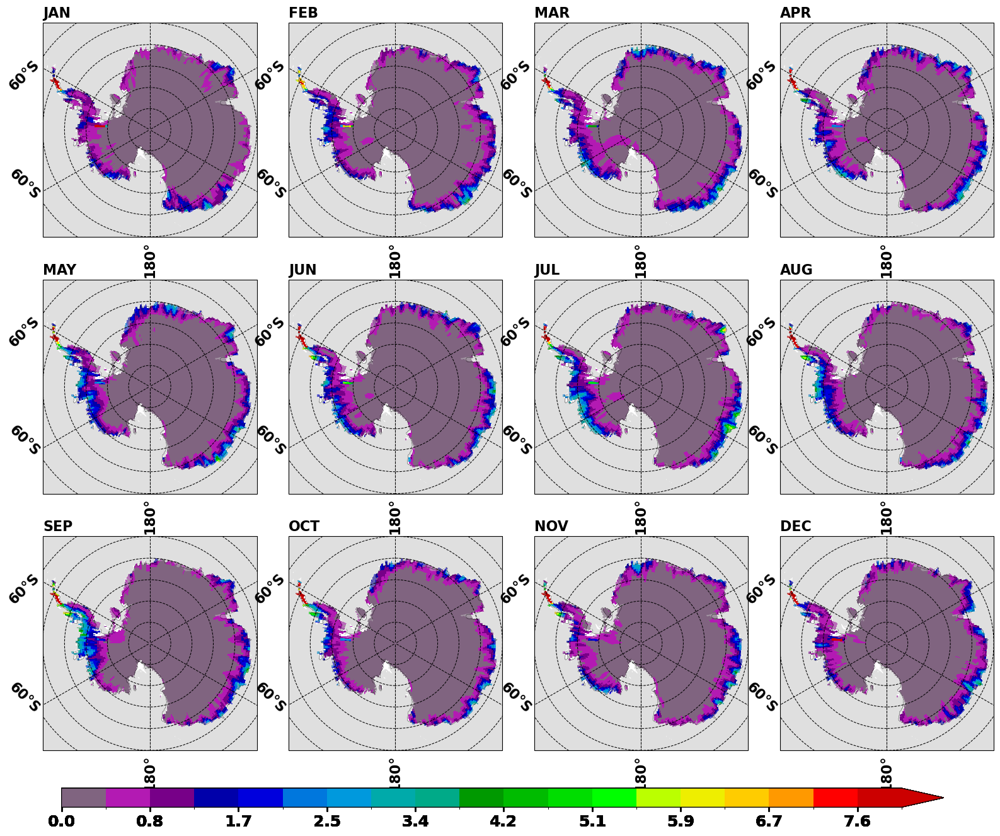

In [ ]:
plot_correction_ratios(cs_ant_month_clim_aligned, vmin=0, vmax=8)

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

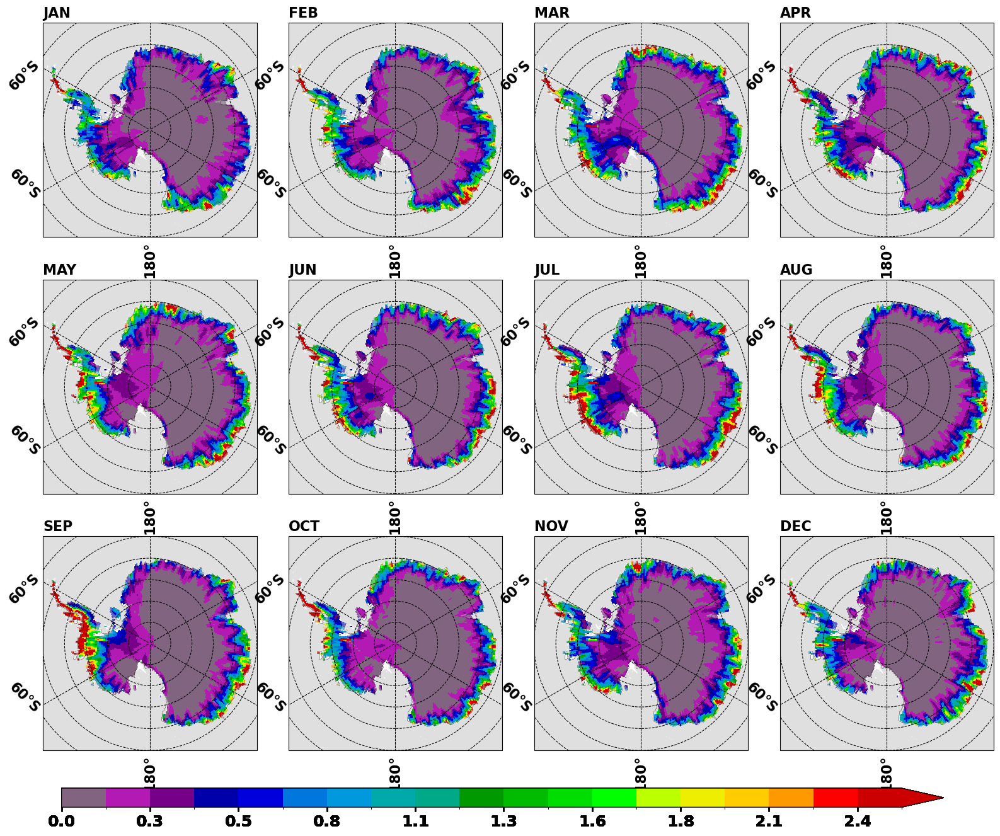

In [ ]:
plot_correction_ratios(cs_ant_month_clim_aligned, vmin=0, vmax=2.5)

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

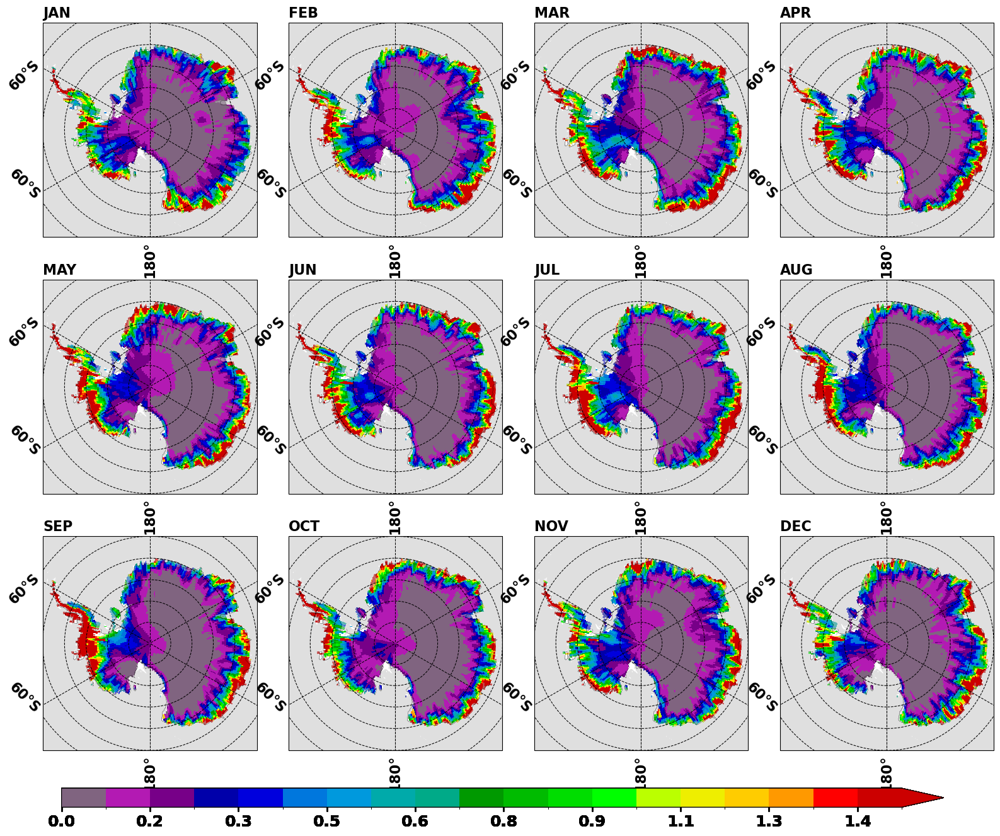

In [ ]:
plot_correction_ratios(cs_ant_month_clim_aligned, vmin=0, vmax=1.5)

<ipython-input-34-6a0e8ecb9984>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  mpl_cm = plt.cm.get_cmap("nipy_spectral", 21)
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for the colorbar
<ipython-input-34-6a0e8ecb9984>:84: 

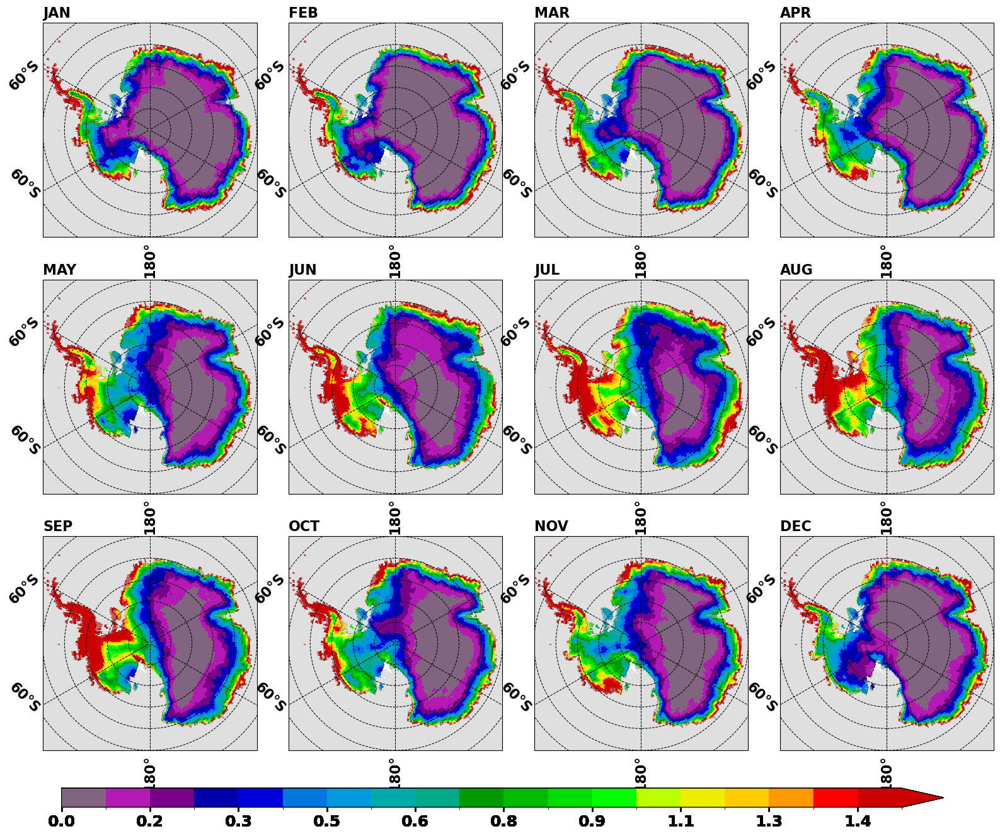

In [ ]:
plot_correction_ratios(gpcp_ant_monthly_clim, vmin=0, vmax=1.5)

In [ ]:
gpcp_zon = get_zonal(gpcp_ant_monthly_clim, mask, y, axis=(0, 1))

NameError: name 'y' is not defined

In [ ]:
gpcp_zon = get_zonal(gpcp_ant_monthly_clim, mask, gpcp_ant_monthly_clim.latitude.values, axis=(0, 1))

ValueError: operands could not be broadcast together with shapes (720,60) (60,1) () 

In [ ]:
gpcp_zon = [
    get_zonal(
        gpcp_ant_monthly_clim.sel(month=month), 
        new_mask_, 
        gpcp_ant_monthly_clim.latitude.values, 
        axis=(0, 1)
    ) 
    for month in range(1, 13)
]

In [ ]:
cs_ant_zon = [
    get_zonal(
        cs_ant_month_clim_aligned.sel(month=month), 
        new_mask_, 
        cs_ant_month_clim_aligned.latitude.values, 
        axis=(0, 1)
    ) 
    for month in range(1, 13)
]

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

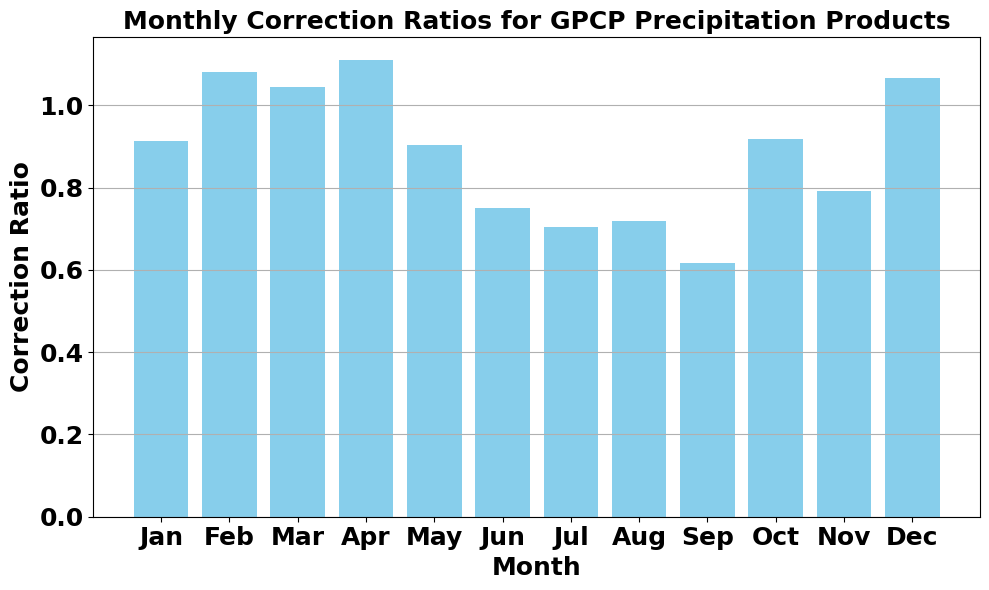

In [ ]:
# calculate ration and plot bar
crfs_arr_single_zon = [
    {
        'month': month,
        'crf': (cs_ant_zon[month - 1].mean().item() / gpcp_zon[month - 1].mean().item())
    }
    for month in range(1, 13)
]

# Convert the list of dictionaries to a DataFrame
crfs_arr_single_zon = pd.DataFrame(crfs_arr_single_zon)

# make a bar plot of the single value correction ratios
# Update matplotlib parameters for improved aesthetics
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Create the bar plot with updated styles
plt.figure(figsize=(10, 6))
plt.bar(crfs_arr_single_zon['month'], crfs_arr_single_zon['crf'], color='skyblue')
plt.xticks(crfs_arr_single_zon['month'], 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios for GPCP Precipitation Products', fontsize=18, fontweight='bold', family='Times New Roman')
plt.grid(axis='y')
plt.tight_layout()

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

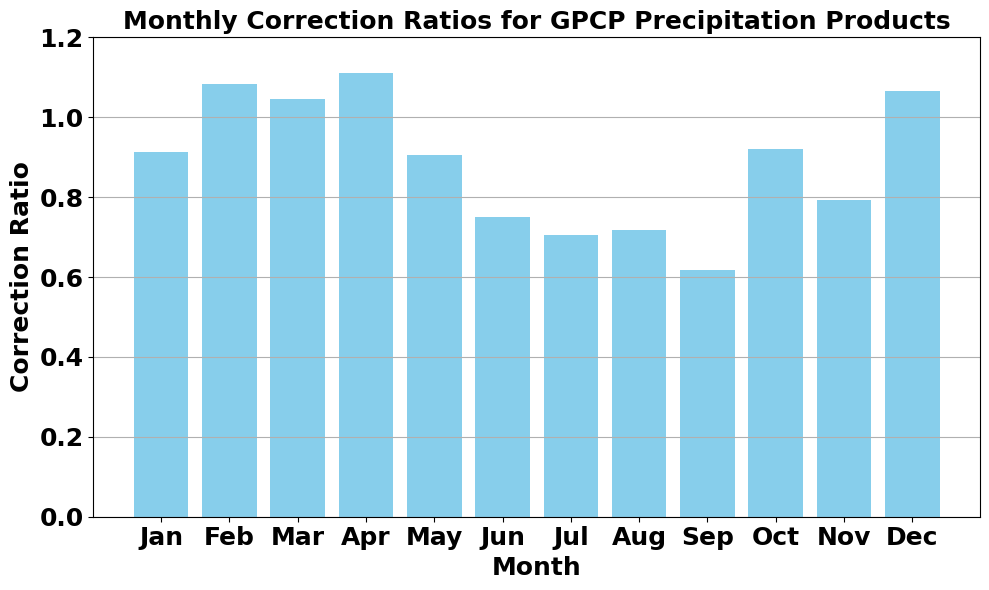

In [ ]:
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18

# Create the bar plot with updated styles
plt.figure(figsize=(10, 6))
plt.bar(crfs_arr_single_zon['month'], crfs_arr_single_zon['crf'], color='skyblue')
plt.xticks(crfs_arr_single_zon['month'], 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
           fontsize=18, fontweight='bold', family='Times New Roman')
plt.xlabel('Month', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylabel('Correction Ratio', fontsize=18, fontweight='bold', family='Times New Roman')
plt.title('Monthly Correction Ratios for GPCP Precipitation Products', fontsize=18, fontweight='bold', family='Times New Roman')
plt.ylim(0, 1.2)  # Adjust y-axis scale to match the previous plots
plt.grid(axis='y')
plt.tight_layout()